In [ ]:
# Importar Librerias
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import threading
from dash import Dash, html, dcc, Input, Output, callback
from pyngrok import ngrok

# Utilizar Plotly dash para los Dashboards. Ngrok para acceder a la URL del dashbord
!pip install dash plotly pandas pyngrok -q
from dash import Dash, html, dcc, Input, Output

# Evitar warnings innecesarios
import warnings
warnings.filterwarnings("ignore")


In [ ]:
# ======================================================================
# Actividad 1: Análisis Masivo de Datos - Parte 1
# ======================================================================

# 1. Cargar datos
# Carga JSON (datos en json_data[1])
with open('/content/sample_data/SH.IMM.json', 'r') as f:
    json_data = json.load(f)
df_json = pd.json_normalize(json_data[1])  # Normaliza el array de datos

# Carga CSV
df_csv = pd.read_csv('/content/sample_data/global_vaccination_coverage.csv')


In [ ]:
# Paso 2: Identificar problemas
print("JSON Info:")
print(df_json.info())  # Tipos, no-nulos
print(df_json.describe())  # Outliers? (value max ~94, min ~69, ok para %)
print("Duplicados JSON:", df_json.duplicated().sum())  # Debería ser 0

print("\nCSV Info:")
print(df_csv.info())
print(df_csv.describe())
print("Duplicados CSV:", df_csv.duplicated().sum())  # 0

# Muestra Valores faltantes
print("\nFaltantes JSON:", df_json.isnull().sum())  # Muchos en unit, obs_status (ignorar)
print("Faltantes CSV:", df_csv.isnull().sum())  # Muchos en columnas de vacunas específicas

JSON Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   countryiso3code  50 non-null     object 
 1   date             50 non-null     object 
 2   value            50 non-null     float64
 3   unit             50 non-null     object 
 4   obs_status       50 non-null     object 
 5   decimal          50 non-null     int64  
 6   indicator.id     50 non-null     object 
 7   indicator.value  50 non-null     object 
 8   country.id       50 non-null     object 
 9   country.value    50 non-null     object 
dtypes: float64(1), int64(1), object(8)
memory usage: 4.0+ KB
None
           value  decimal
count  50.000000     50.0
mean   85.423150      0.0
std     7.424348      0.0
min    69.027889      0.0
25%    81.528107      0.0
50%    87.756654      0.0
75%    91.984944      0.0
max    93.958411      0.0
Duplicados JSON: 0

CSV Info:
<cl

In [ ]:
# 3. Limpieza

# JSON: Renombrar columnas para estandarizar, filtrar años >=2020
df_json_clean = df_json.rename(columns={
    'country.value': 'Region',
    'date': 'Year',
    'value': 'DPT_Coverage_Percent'
})
df_json_clean = df_json_clean[['Region', 'Year', 'DPT_Coverage_Percent']]  # Mantener relevantes
df_json_clean['Year'] = df_json_clean['Year'].astype(int)  # Convertir a int
df_json_clean = df_json_clean[df_json_clean['Year'] >= 2020]  # Filtrar recientes

# Imputación: No faltantes en value, pero si hay, usa media
df_json_clean['DPT_Coverage_Percent'].fillna(df_json_clean['DPT_Coverage_Percent'].mean(), inplace=True)

# CSV: Filtrar años >=2020 y entidades relevantes
df_csv_clean = df_csv.rename(columns={
    'Entity': 'Country',
    'Code': 'Country_Code',
    'Year': 'Year',
    'Share of one-year-olds who have had three doses of the diphtheria, tetanus and pertussis vaccine': 'DPT_Coverage_Percent'
})

# Filtrar columnas relevantes
df_csv_clean = df_csv_clean[['Country', 'Country_Code', 'Year', 'DPT_Coverage_Percent']]
df_csv_clean = df_csv_clean[df_csv_clean['Year'] >= 2020]  # Filtrar recientes

# Eliminar duplicados
df_csv_clean.drop_duplicates(inplace=True)

# Imputación de faltantes: Para DPT, usa media por país
df_csv_clean['DPT_Coverage_Percent'] = df_csv_clean.groupby('Country')['DPT_Coverage_Percent'].transform(lambda x: x.fillna(x.mean()))

# Eliminar rows con NaN restantes
df_csv_clean.dropna(subset=['DPT_Coverage_Percent'], inplace=True)

# Detectar outliers: Asumir >100 o <0 como error, clippear
df_csv_clean['DPT_Coverage_Percent'] = np.clip(df_csv_clean['DPT_Coverage_Percent'], 0, 100)

In [ ]:
# 4. Transformaciones e integración
# Crear mapeo de países a regiones (basado en OMS/Banco Mundial, parcial para los datos visibles)
region_mapping = {
    # Africa
    'NGA': 'Africa', 'KEN': 'Africa', 'ETH': 'Africa', 'ZAF': 'Africa', 'GHA': 'Africa',
    'TZA': 'Africa', 'UGA': 'Africa', 'COD': 'Africa', 'AGO': 'Africa', 'MOZ': 'Africa',
    # Americas
    'BRA': 'Americas', 'MEX': 'Americas', 'USA': 'Americas', 'ARG': 'Americas', 'COL': 'Americas',
    'PER': 'Americas', 'CHL': 'Americas', 'CAN': 'Americas',
    # South-East Asia
    'IND': 'South-East Asia', 'IDN': 'South-East Asia', 'BGD': 'South-East Asia',
    'THA': 'South-East Asia', 'MMR': 'South-East Asia',
    # Europe
    'DEU': 'Europe', 'FRA': 'Europe', 'ITA': 'Europe', 'ESP': 'Europe', 'GBR': 'Europe',
    'RUS': 'Europe', 'UKR': 'Europe', 'POL': 'Europe',
    # Eastern Mediterranean
    'AFG': 'Eastern Mediterranean', 'YEM': 'Eastern Mediterranean',
    'PAK': 'Eastern Mediterranean', 'EGY': 'Eastern Mediterranean', 'IRN': 'Eastern Mediterranean',
    'SAU': 'Eastern Mediterranean', 'IRQ': 'Eastern Mediterranean', 'MAR': 'Eastern Mediterranean',
    # Western Pacific
    'CHN': 'Western Pacific', 'PHL': 'Western Pacific', 'JPN': 'Western Pacific',
    'AUS': 'Western Pacific', 'KOR': 'Western Pacific', 'VNM': 'Western Pacific', 'NZL': 'Western Pacific'
}

# Agregar columna de región al CSV usando mapeo
df_csv_clean['Region'] = df_csv_clean['Country_Code'].map(region_mapping)

# Filtrar años comunes (2020-2024) para consistencia
df_csv_clean = df_csv_clean[df_csv_clean['Year'].isin([2020, 2021, 2022, 2023, 2024])]
df_json_clean = df_json_clean[df_json_clean['Year'].isin([2020, 2021, 2022, 2023, 2024])]

# Concatenar: Tratar regiones como 'Entity' para unificar (renombrar 'Country' y 'Region' a 'Entity')
df_combined = pd.concat([
    df_csv_clean[['Country', 'Year', 'DPT_Coverage_Percent', 'Region']].rename(columns={'Country': 'Entity'}),
    df_json_clean[['Region', 'Year', 'DPT_Coverage_Percent']].rename(columns={'Region': 'Entity'})
], ignore_index=True)

# Agregar columna fuente para distinguir origen
df_combined['Source'] = df_combined['Entity'].apply(lambda x: 'World Bank' if x in df_json_clean['Region'].values else 'OWID')

# Guardar dataset unificado
df_combined.to_csv('/content/sample_data/vaccination_unified.csv', index=False)



In [ ]:
# Print de datos combinado
print("\nDatos limpios combinados:")
print(df_combined.head(10))
print(df_combined.shape)


Datos limpios combinados:
         Entity  Year  DPT_Coverage_Percent                 Region Source
0   Afghanistan  2020             61.000000  Eastern Mediterranean   OWID
1   Afghanistan  2021             55.000000  Eastern Mediterranean   OWID
2   Afghanistan  2022             58.000000  Eastern Mediterranean   OWID
3   Afghanistan  2023             60.000000  Eastern Mediterranean   OWID
4   Afghanistan  2024             59.000000  Eastern Mediterranean   OWID
5        Africa  2020             75.566820                    NaN   OWID
6        Africa  2021             74.685140                    NaN   OWID
7        Africa  2022             74.559580                    NaN   OWID
8        Africa  2023             75.851456                    NaN   OWID
9  Africa (WHO)  2020             74.000000                    NaN   OWID
(1134, 5)


In [ ]:
# Paso 5. Verificación cruzada para validar consistencia
# Calcular promedio DTP3 por región en el CSV y comparar con JSON
csv_region_avg = df_csv_clean.groupby(['Region', 'Year'])['DPT_Coverage_Percent'].mean().reset_index()
json_region = df_json_clean[['Region', 'Year', 'DPT_Coverage_Percent']]
comparison = pd.merge(
    csv_region_avg,
    json_region,
    on=['Region', 'Year'],
    how='inner',
    suffixes=('_CSV', '_JSON')
)
print("\nComparación CSV vs JSON (promedios por región):")
print(comparison)


Comparación CSV vs JSON (promedios por región):
Empty DataFrame
Columns: [Region, Year, DPT_Coverage_Percent_CSV, DPT_Coverage_Percent_JSON]
Index: []


In [ ]:
# ======================================================================
# Actividad 2: Análisis Masivo de Datos - Parte 2
# Usando el dataset combinado de la Actividad 1 (df_combined)
# ======================================================================

# Análisis descriptivo
# Seleccionamos 4 variables clave: Year, DPT_Coverage_Percent, Entity (conteo único), Region (distribución)
# Resumen estadístico
print("\nResumen descriptivo de variables clave:")
summary = df_combined[['Year', 'DPT_Coverage_Percent']].describe()
print(summary)

# Tabla de promedios por año
avg_by_year = df_combined.groupby('Year')['DPT_Coverage_Percent'].mean().reset_index()
print("\nPromedio de cobertura DPT por año:")
print(avg_by_year)

# Tabla de promedios por región (solo donde Region no es NaN)
avg_by_region = df_combined.groupby('Region')['DPT_Coverage_Percent'].mean().reset_index().dropna()
print("\nPromedio de cobertura DPT por región:")
print(avg_by_region)

# Conteo de entidades únicas
unique_entities = df_combined['Entity'].nunique()
print(f"\nNúmero de entidades únicas (países/regiones): {unique_entities}")


Resumen descriptivo de variables clave:
              Year  DPT_Coverage_Percent
count  1134.000000           1134.000000
mean   2021.989418             85.806361
std       1.411050             12.714580
min    2020.000000             32.000000
25%    2021.000000             79.000000
50%    2022.000000             90.000000
75%    2023.000000             95.750000
max    2024.000000             99.000000

Promedio de cobertura DPT por año:
   Year  DPT_Coverage_Percent
0  2020             85.719924
1  2021             84.881003
2  2022             86.067673
3  2023             86.062507
4  2024             86.314059

Promedio de cobertura DPT por región:
                  Region  DPT_Coverage_Percent
0                 Africa             76.560000
1               Americas             85.600000
2  Eastern Mediterranean             83.600000
3                 Europe             92.300000
4        South-East Asia             85.120000
5        Western Pacific             91.857143

Númer

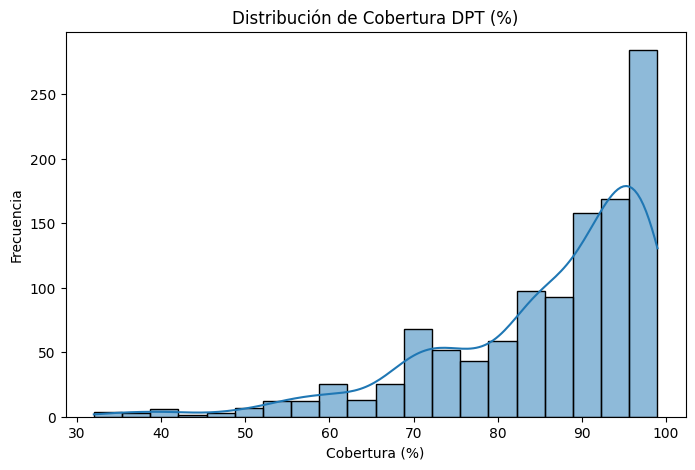

In [ ]:
# Generacion de Graficos

# Gráfico 1: Distribución de cobertura DPT
plt.figure(figsize=(8, 5))
sns.histplot(df_combined['DPT_Coverage_Percent'], bins=20, kde=True)
plt.title('Distribución de Cobertura DPT (%)')
plt.xlabel('Cobertura (%)')
plt.ylabel('Frecuencia')
plt.show()

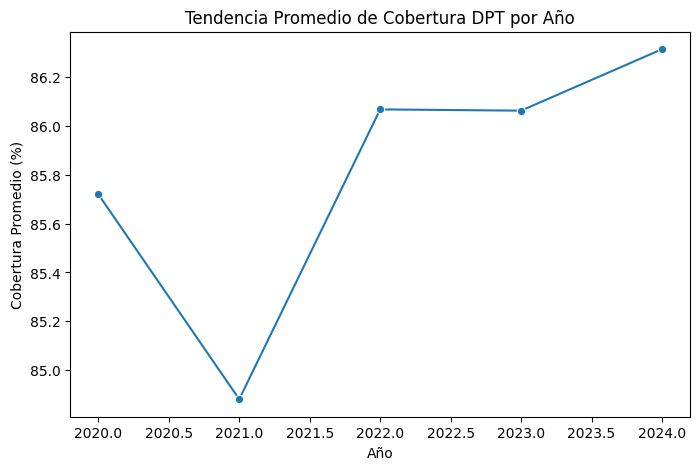

In [ ]:
# Gráfico 2: Tendencia promedio por año
plt.figure(figsize=(8, 5))
sns.lineplot(data=avg_by_year, x='Year', y='DPT_Coverage_Percent', marker='o')
plt.title('Tendencia Promedio de Cobertura DPT por Año')
plt.xlabel('Año')
plt.ylabel('Cobertura Promedio (%)')
plt.show()

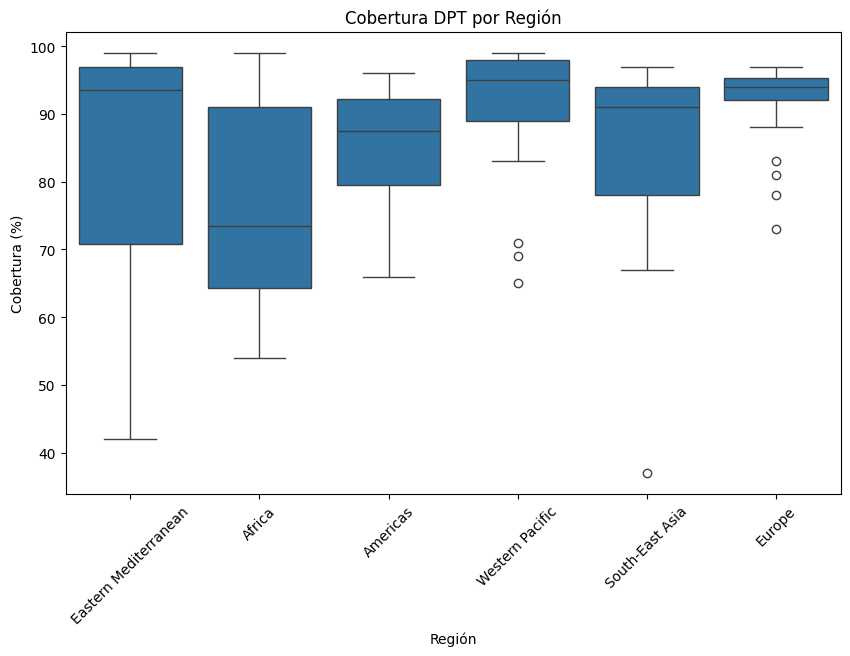

In [ ]:
# Gráfico 3: Boxplot por región
if not avg_by_region.empty:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_combined.dropna(subset=['Region']), x='Region', y='DPT_Coverage_Percent')
    plt.title('Cobertura DPT por Región')
    plt.xlabel('Región')
    plt.ylabel('Cobertura (%)')
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
# Patrones identificados: La cobertura promedio parece estable o con ligera baja post-2020 (posible impacto COVID). Regiones como Eastern Mediterranean muestran variabilidad mayor.

# Aplicación de un modelo predictivo sencillo
# Modelo elegido: Regresión Lineal Simple (usando Year para predecir DPT_Coverage_Percent a nivel global promedio).
# Explicación conceptual: Elegimos regresión lineal porque es un modelo simple para capturar tendencias lineales en series temporales. Aquí, asumimos que la cobertura DPT podría tener una relación lineal con el tiempo (ej. mejoras o declives graduales debido a políticas de salud globales). Es interpretable y no requiere datos complejos.

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Preparar datos: Usar promedios anuales para simplicidad (evitar multicolinealidad por entidades)
df_model = avg_by_year.copy()  # Year vs Promedio DPT

X = df_model[['Year']]  # Predictor: Año
y = df_model['DPT_Coverage_Percent']  # Target: Cobertura promedio

# Dividir en train/test (80/20, aunque dataset pequeño)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Aplicar modelo
model = LinearRegression()
model.fit(X_train, y_train)

# Predicciones
y_pred = model.predict(X_test)


R² del modelo: nan
Predicción de cobertura promedio para 2025: 86.42%


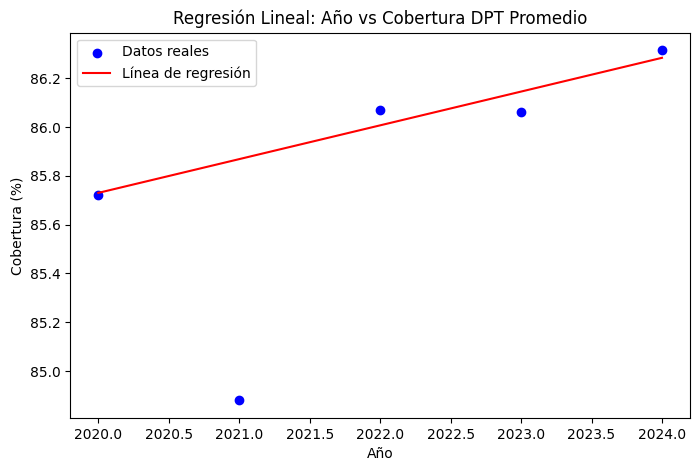

In [ ]:
# Evaluación básica del modelo
# Métrica: R² (coeficiente de determinación)
r2 = r2_score(y_test, y_pred)
print(f"\nR² del modelo: {r2:.2f}")

# Interpretación: Un R² de X significa que el X% de la variabilidad en la cobertura DPT se explica por el año. Para este caso, indica si hay una tendencia lineal fuerte (ej. si R² > 0.7, el modelo captura bien el declive/ascenso temporal); si es bajo, sugiere que factores no lineales (como pandemias) influyen más.

# Predicción ejemplo: Para 2025
pred_2025 = model.predict([[2025]])
print(f"Predicción de cobertura promedio para 2025: {pred_2025[0]:.2f}%")

# Gráfico de regresión
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', label='Datos reales')
plt.plot(X, model.predict(X), color='red', label='Línea de regresión')
plt.title('Regresión Lineal: Año vs Cobertura DPT Promedio')
plt.xlabel('Año')
plt.ylabel('Cobertura (%)')
plt.legend()
plt.show()

# **5. Conclusión**

**Información útil**: El análisis muestra tendencias en cobertura DPT, ayudando a decisiones como priorizar regiones con baja cobertura (ej. Eastern Mediterranean) para la realizacion de posteriores campañas de vacunación. El modelo predictivo puede estimar futuros declives, alertando sobre necesidades de intervención.

**Limitaciones**: Dataset limitado a 5 años recientes, lo que reduce robustez para predicciones largas; mapeo de regiones incompleto (muchos NaN); modelo simple ignora variables externas (ej. PIB, conflictos); posibles sesgos en estimaciones OMS/UNICEF.

In [ ]:
# ======================================================================
# Actividad 3: Dashboard Interactivo con Dash + Plotly + ngrok
# Dataset: vaccination_unified.csv (generado en Actividad 1 y 2)
# ======================================================================


# Configurar Ngrok
# El token de autenticación se moverá al final de la celda de ejecución del dashboard
# Ir a https://dashboard.ngrok.com/get-started/your-authtoken para cambiar el token


In [ ]:
# Cargar el dataSet unificado
df = pd.read_csv('/content/sample_data/vaccination_unified.csv')

In [ ]:
# Calculos estadisticos basicos (para KPIs)
global_mean = df['DPT_Coverage_Percent'].mean()
global_median = df['DPT_Coverage_Percent'].median()
global_std = df['DPT_Coverage_Percent'].std()
total_entities = df['Entity'].nunique()

# Regla de negocio: Meta OMS = 90% de cobertura DPT3
oms_target = 90
alert_threshold = 80  # Alerta si promedio < 80%

In [ ]:
# Preparar datos para graficos

# Evolución temporal (línea)
df_yearly = df.groupby('Year')['DPT_Coverage_Percent'].mean().reset_index()

# Barras: Promedio por región (solo regiones con datos)
df_region = df.dropna(subset=['Region'])
df_region_avg = df_region.groupby('Region')['DPT_Coverage_Percent'].mean().reset_index()
df_region_avg = df_region_avg.sort_values('DPT_Coverage_Percent', ascending=False)

In [ ]:
# Crear graficos con Plotly
# Gráfico 1: Línea - Evolución temporal
fig_line = px.line(
    df_yearly,
    x='Year',
    y='DPT_Coverage_Percent',
    title='Evolución de la Cobertura DPT3 Global (2020-2024)',
    markers=True,
    line_shape='linear'
)
fig_line.add_hline(y=oms_target, line_dash="dash", line_color="green", annotation_text="Meta OMS: 90%")
fig_line.add_hline(y=alert_threshold, line_dash="dot", line_color="red", annotation_text="Alerta: <80%")
fig_line.update_layout(
    yaxis_title="Cobertura (%)",
    xaxis_title="Año",
    xaxis=dict(tickmode='array', tickvals=df_yearly['Year']),
    height=380
)

# Gráfico 2: Barras - Promedio por región
# Función para asignar color y etiqueta según umbrales OMS
def assign_risk(row):
    if row['DPT_Coverage_Percent'] < 80:
        return pd.Series(["crimson", "ALERTA"])
    elif row['DPT_Coverage_Percent'] < 90:
        return pd.Series(["#f39c12", "ADVERTENCIA"])  # Naranja
    else:
        return pd.Series(["#27ae60", "ÓPTIMO"])       # Verde

# Aplicar reglas
df_region_avg[['Risk_Color', 'Risk_Label']] = df_region_avg.apply(assign_risk, axis=1)

# Ordenar: primero ALERTA, luego ADVERTENCIA, luego ÓPTIMO
order = {'ALERTA': 0, 'ADVERTENCIA': 1, 'ÓPTIMO': 2}
df_region_avg = df_region_avg.sort_values(
    by='Risk_Label',
    key=lambda x: x.map(order)
)

# Crear gráfico con colores por riesgo
fig_bar = go.Figure()

fig_bar.add_trace(go.Bar(
    y=df_region_avg['Region'],
    x=df_region_avg['DPT_Coverage_Percent'],
    orientation='h',
    text=df_region_avg['DPT_Coverage_Percent'].round(1).astype(str) + '%',
    textposition='outside',
    marker_color=df_region_avg['Risk_Color'],
    hovertemplate=
        "<b>%{y}</b><br>" +
        "Cobertura: %{x:.1f}%<br>" +
        "Estado: <b>%{customdata[0]}</b><extra></extra>",
    customdata=df_region_avg[['Risk_Label']]
))

# Líneas de umbral
fig_bar.add_vline(x=80, line_dash="dash", line_color="red", annotation_text="Alerta 80%")
fig_bar.add_vline(x=90, line_dash="dash", line_color="green", annotation_text="Meta OMS 90%")

# Título con leyenda de colores
fig_bar.update_layout(
    title={
        'text': "Cobertura DPT3 por Región OMS (2020-2024)<br>"
                "<sub>Color: <span style='color:crimson;font-weight:bold'>ALERTA &lt;80%</span> | "
                "<span style='color:#f39c12;font-weight:bold'>ADVERTENCIA 80-89%</span> | "
                "<span style='color:#27ae60;font-weight:bold'>ÓPTIMO ≥90%</span></sub>",
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 16}
    },
    xaxis=dict(range=[0, 100], title="Cobertura Promedio (%)", tick0=0, dtick=10),
    yaxis=dict(title="Región"),
    height=450,
    margin=dict(l=160, r=60, t=100, b=60),
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family="Arial", size=12)
)

fig_bar.update_traces(textfont_size=12, cliponaxis=False)

In [ ]:
# Crear Dashboard
app = Dash(__name__)

app.layout = html.Div([
    html.H1("Dashboard: Cobertura Vacunal DPT3 (2020-2024)",
            style={'textAlign': 'center', 'color': '#1f77b4', 'fontFamily': 'Arial', 'marginBottom': 5}),

    html.P("Fuente: OWID + World Bank | Datos unificados y limpiados",
           style={'textAlign': 'center', 'color': '#555', 'fontSize': 14, 'marginBottom': 20}),

    # === KPIs ===
    html.Div([
        html.Div([
            html.H3(f"{global_mean:.1f}%", style={'color': '#2E86C1', 'margin': '5px', 'fontSize': 28}),
            html.P("Cobertura Promedio Global", style={'margin': '2px', 'fontSize': 13})
        ], className="four columns", style={'textAlign': 'center', 'backgroundColor': '#f0f8ff', 'padding': '15px', 'borderRadius': '10px', 'margin': '10px'}),

        html.Div([
            html.H3(f"{total_entities}", style={'color': '#28A745', 'margin': '5px', 'fontSize': 28}),
            html.P("Países/Regiones Analizados", style={'margin': '2px', 'fontSize': 13})
        ], className="four columns", style={'textAlign': 'center', 'backgroundColor': '#f0fff0', 'padding': '15px', 'borderRadius': '10px', 'margin': '10px'}),

        html.Div([
            html.H3(f"{global_std:.1f}%", style={'color': '#DC3545', 'margin': '5px', 'fontSize': 28}),
            html.P("Desviación Estándar", style={'margin': '2px', 'fontSize': 13})
        ], className="four columns", style={'textAlign': 'center', 'backgroundColor': '#fff0f0', 'padding': '15px', 'borderRadius': '10px', 'margin': '10px'}),
    ], className="row", style={'marginBottom': '20px'}),

    # === REGLAS DE NEGOCIO ===
    html.Div([
        html.P([
            html.Strong("Reglas de Negocio: "),
            "• < 80%: ", html.Span("ALERTA ROJA", style={'color': 'red', 'fontWeight': 'bold'}),
            " → Intervención urgente | ",
            "• < 90%: ", html.Span("ADVERTENCIA", style={'color': 'orange', 'fontWeight': 'bold'}),
            " → Monitoreo intensivo | ",
            "• ≥ 90%: ", html.Span("ÓPTIMO", style={'color': 'green', 'fontWeight': 'bold'})
        ], style={'backgroundColor': '#fff3cd', 'padding': '12px', 'borderRadius': '8px', 'fontSize': 14, 'border': '1px solid #ffeaa7'})
    ], style={'margin': '15px 0'}),

    # === GRÁFICOS ===
    html.Div([
        html.Div([dcc.Graph(figure=fig_line)], className="six columns"),
        html.Div([dcc.Graph(figure=fig_bar)], className="six columns"),
    ], className="row", style={'marginTop': '10px'}),

    # === EXPLICACIÓN DE INDICADORES ===
    html.Div([
        html.H4("Indicadores Clave y Justificación", style={'color': '#2c3e50'}),
        html.Ul([
            html.Li("Cobertura Promedio Global: KPI principal de OMS para medir éxito de programas de inmunización."),
            html.Li("Evolución Temporal: Detecta caídas (ej. post-COVID) y evalúa recuperación."),
            html.Li("Desviación Estándar: Mide inequidad entre países. Alta → priorizar rezagados."),
            html.Li("Cobertura por Región: Permite focalizar intervenciones geográficas."),
        ], style={'fontSize': 14, 'lineHeight': 1.6})
    ], style={'margin': '30px', 'backgroundColor': '#f8f9fa', 'padding': '18px', 'borderRadius': '10px', 'border': '1px solid #dee2e6'})

], style={
    'padding': '25px',
    'fontFamily': 'Arial, sans-serif',
    'backgroundColor': '#f4f6f9',
    'minHeight': '100vh'
})

In [ ]:
# Ejecutar Dashboard con acceso a URL mediante Ngrok
from pyngrok import ngrok
def run_dash():
    app.run(host='0.0.0.0', port=8050, debug=False)

# Iniciar en hilo
threading.Thread(target=run_dash, daemon=True).start()

# Establecer el token de autenticación de ngrok antes de conectar
ngrok.set_auth_token("2w8NpK1U8Uv2ok0t6KTbzcYfaPP_TW5neUdksuTRH48GodR7")

# Asegurarse de que no haya túneles previos abiertos que bloqueen la conexión
ngrok.kill()

# Exponer con ngrok
public_url = ngrok.connect(8050)
print("\n" + "="*80)
print("DASHBOARD ACTIVIDAD III LISTO - VERSIÓN MEJORADA")
print("="*80)
print(f"URL PÚBLICA: {public_url}")
print("="*80)
print("Haz clic arriba para abrir el dashboard")
print("Toma capturas de: KPIs, gráficos, alertas y explicación")
print("="*80 + "\n")

Dash is running on http://0.0.0.0:8050/



INFO:dash.dash:Dash is running on http://0.0.0.0:8050/



 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:8050
 * Running on http://172.28.0.12:8050
INFO:werkzeug:Press CTRL+C to quit



DASHBOARD ACTIVIDAD III LISTO - VERSIÓN MEJORADA
URL PÚBLICA: NgrokTunnel: "https://63dd925574e8.ngrok-free.app" -> "http://localhost:8050"
Haz clic arriba para abrir el dashboard
Toma capturas de: KPIs, gráficos, alertas y explicación

